In [2]:
import logging
logging.basicConfig(
    level=logging.WARNING,
    format='%(asctime)s %(levelname)s %(name)s: %(message)s'
)
logger = logging.getLogger(__name__)

import json
import os
import sys
import yaml
from glob import glob
from collections import defaultdict
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tqdm import tqdm
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy import table, time

import galsim
from galsim import roman
from romanisim import image, parameters, catalog, psf, util, wcs
import romanisim.bandpass

import mejiro
from mejiro.utils import util as mejiro_util

# read config
config_file = os.path.join(os.path.dirname(mejiro.__file__), 'data', 'mejiro_config', 'roman_data_challenge_rung_1.yaml')
with open(config_file, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)
if config['dev']:
    config['pipeline_label'] += '_dev'

rng = galsim.UniformDeviate(42)

In [3]:
# discover SCA directories and group SyntheticImage pickles by SCA and band
data_dir = os.path.join(config['data_dir'], config['pipeline_label'], '04')

sca_dirs = sorted(glob(os.path.join(data_dir, 'sca*')))
print(f'Found {len(sca_dirs)} SCA directories in {data_dir}')

pickles_by_sca_band = {}
for sca_dir in sca_dirs:
    sca_name = os.path.basename(sca_dir)
    sca_num = int(sca_name[3:])

    sca_pickles = sorted(glob(os.path.join(sca_dir, 'SyntheticImage_*.pkl')))

    by_band = defaultdict(list)
    for p in sca_pickles:
        bn = os.path.basename(p)
        parts = bn.replace('.pkl', '').split('_')
        band = parts[-1]
        by_band[band].append(p)

    pickles_by_sca_band[sca_num] = dict(by_band)
    for band, ps in sorted(by_band.items()):
        print(f'  SCA {sca_num:02d}, {band}: {len(ps)} pickles')

Found 18 SCA directories in /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/04
  SCA 01, F106: 5734 pickles
  SCA 01, F129: 5734 pickles
  SCA 01, F158: 5734 pickles
  SCA 02, F106: 5719 pickles
  SCA 02, F129: 5719 pickles
  SCA 02, F158: 5719 pickles
  SCA 03, F106: 5875 pickles
  SCA 03, F129: 5875 pickles
  SCA 03, F158: 5875 pickles
  SCA 04, F106: 5823 pickles
  SCA 04, F129: 5823 pickles
  SCA 04, F158: 5823 pickles
  SCA 05, F106: 5962 pickles
  SCA 05, F129: 5962 pickles
  SCA 05, F158: 5962 pickles
  SCA 06, F106: 6014 pickles
  SCA 06, F129: 6014 pickles
  SCA 06, F158: 6014 pickles
  SCA 07, F106: 5929 pickles
  SCA 07, F129: 5929 pickles
  SCA 07, F158: 5929 pickles
  SCA 08, F106: 5953 pickles
  SCA 08, F129: 5953 pickles
  SCA 08, F158: 5953 pickles
  SCA 09, F106: 6073 pickles
  SCA 09, F129: 6073 pickles
  SCA 09, F158: 6073 pickles
  SCA 10, F106: 5794 pickles
  SCA 10, F129: 5794 pickles
  SCA 10, F158: 5794 pickles
  SCA 11, F106: 5921 pickles
  SCA 11, F129: 59

In [4]:
# tiling and simulation parameters
TILE_SIZE = 73
GRID_SIDE = 56
N_TILES = GRID_SIDE * GRID_SIDE  # 3136

bands = config['synthetic_image']['bands']
exposure_time = config['imaging']['exposure_time']

# output directory
output_dir = os.path.join(config['data_dir'], config['pipeline_label'], '05_romanisim')
os.makedirs(output_dir, exist_ok=True)

print(f'Tile size: {TILE_SIZE}x{TILE_SIZE}')
print(f'Grid: {GRID_SIDE}x{GRID_SIDE} = {N_TILES} tiles per band')
print(f'Full array: {GRID_SIDE * TILE_SIZE}x{GRID_SIDE * TILE_SIZE}')
print(f'Bands: {bands}')
print(f'Exposure time: {exposure_time} s')

Tile size: 73x73
Grid: 56x56 = 3136 tiles per band
Full array: 4088x4088
Bands: ['F106', 'F129', 'F158']
Exposure time: 139.1 s


In [6]:
parameters.read_pattern.keys()

dict_keys([3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 109, 110])

In [11]:
ma_table_number = 17
date           = "2027-01-01T00:00:00"
coord = SkyCoord(ra=270.0 * u.deg, dec=66.0 * u.deg)

read_pattern = parameters.read_pattern[ma_table_number]
exptime = parameters.read_time * read_pattern[-1][-1]
print(f"Total exposure time (MA table {ma_table_number}): {exptime:.1f} s")

Total exposure time (MA table 17): 610.4 s


In [ ]:
# for each SCA, for each band: tile, simulate with romanisim, extract cutouts
for sca_num, bands_dict in sorted(pickles_by_sca_band.items()):
    sca_output_dir = os.path.join(output_dir, f'sca{str(sca_num).zfill(2)}')
    os.makedirs(sca_output_dir, exist_ok=True)
    mejiro_util.clear_directory(sca_output_dir)

    for band in bands:
        if band not in bands_dict:
            print(f'Skipping SCA {sca_num:02d}, {band}: no pickles found')
            continue

        # get AB flux
        abflux = romanisim.bandpass.get_abflux(band, sca_num)

        band_pickles = bands_dict[band][:N_TILES]
        n_images = len(band_pickles)
        print(f'Processing SCA {sca_num:02d}, {band}: {n_images} images')
        print(f'  AB flux: {abflux:.6e} e-/s per maggy, exptime: {exptime:.6f} s')

        # 1. tile synthetic images into a 4088x4088 extra_counts array
        counts = np.zeros((4088, 4088), dtype=np.float64)
        n_bad_tiles = 0
        max_tile_value = -np.inf
        min_tile_value = np.inf

        for idx, pickle_path in enumerate(tqdm(band_pickles, desc='Loading')):
            # load synthetic image
            synth = mejiro_util.unpickle(pickle_path)

            # deal with negative and nan pixels
            smooth_data = np.asarray(mejiro_util.smooth_pixels(synth.data), dtype=np.float64)

            # convert the units
            synth_sum = np.sum(smooth_data, dtype=np.float64)
            maggies = synth.get_maggies()
            total_electrons = maggies * abflux * exptime
            lens_electrons = (smooth_data / synth_sum) * total_electrons

            # put it in the right place
            row = idx // GRID_SIDE
            col = idx % GRID_SIDE
            r0 = row * TILE_SIZE
            c0 = col * TILE_SIZE
            counts[r0:r0 + TILE_SIZE, c0:c0 + TILE_SIZE] = lens_electrons

        plt.imshow(counts, norm=LogNorm(), origin='lower')
        plt.colorbar(label='Electrons')
        plt.title(f'SCA {sca_num:02d}, {band} - Tiled Synthetic Images')
        plt.savefig(os.path.join(sca_output_dir, f'sca{sca_num:02d}_{band}_tiled.png'))
        plt.close()

        # 2. add Poisson noise
        print(counts.max(), counts.min(), np.isnan(counts).sum(), np.isinf(counts).sum())
        rng_np = np.random.default_rng(42)
        realized = rng_np.poisson(counts).astype(np.int32)
        extra_counts = galsim.ImageI(realized)  # ImageI for integer type

        # 3. set up romanisim metadata with the correct SCA
        meta = deepcopy(parameters.default_parameters_dictionary)
        meta['instrument']['detector'] = f'WFI{sca_num:02d}'
        meta['instrument']['optical_element'] = band
        meta['exposure']['ma_table_number'] = ma_table_number
        meta['exposure']['read_pattern'] = parameters.read_pattern[ma_table_number]
        meta['exposure']['start_time'] = time.Time(date, format='isot')
        wcs.fill_in_parameters(meta, coord, boresight=True)

        # 4. create source table
        catalog = table.Table({
            'ra': np.array([], dtype='f8'),
            'dec': np.array([], dtype='f8'),
            'type': np.array([], dtype='U3'),
            'n': np.array([], dtype='f4'),
            'half_light_radius': np.array([], dtype='f4'),
            'pa': np.array([], dtype='f4'),
            'ba': np.array([], dtype='f4'),
            band: np.array([], dtype='f4'),
        })

        # 5. simulate
        print(f'  Running romanisim for SCA {sca_num:02d}, {band}...')
        im, extras = image.simulate(
            meta, catalog,
            usecrds=False,
            psftype='galsim',
            level=2,
            rng=rng,
            crparam=dict(),
            extra_counts=extra_counts,
        )

        # save the romanisim output
        mejiro_util.pickle(os.path.join(sca_output_dir, f'im_sca{sca_num:02d}_{band}.pkl'), im)
        mejiro_util.pickle(os.path.join(sca_output_dir, f'extras_sca{sca_num:02d}_{band}.pkl'), extras)

        # 6. extract cutouts and save as .npy
        result_data = im.data
        np.save(os.path.join(sca_output_dir, f'full_array_sca{sca_num:02d}_{band}.npy'), result_data)
        for idx, pickle_path in enumerate(band_pickles):
            row = idx // GRID_SIDE
            col = idx % GRID_SIDE
            r0 = row * TILE_SIZE
            c0 = col * TILE_SIZE
            cutout = result_data[r0:r0 + TILE_SIZE, c0:c0 + TILE_SIZE]

            output_name = os.path.basename(pickle_path).replace('.pkl', '.npy').replace('SyntheticImage_', 'Exposure_')
            np.save(os.path.join(sca_output_dir, output_name), cutout)

        print(f'  Saved {n_images} cutouts to {sca_output_dir}')

Processing SCA 01, F106: 3136 images
  AB flux: 3.358243e+10 e-/s per maggy, exptime: 139.148680 s


Loading:   0%|          | 6/3136 [00:01<07:33,  6.90it/s]/data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/scipy/ndimage/_filters.py:2420: RuntimeWarning: All-NaN slice encountered
  _nd_image.generic_filter(input, function, footprint, output, mode,
Loading: 100%|██████████| 3136/3136 [02:28<00:00, 21.19it/s]


16230.493057262325 3.21853968078159e-07 0 0


2026-04-03 13:07:52,364 WARNING romanisim: --usecrds is not set.  romanisim will not use reference files from CRDS.  The WCS may be incorrect and up-to-date calibration information will not be used.


  Running romanisim for SCA 01, F106...


...

2026-04-03 13:24:21,377 WARNING romanisim: --usecrds is not set.  romanisim will not use reference files from CRDS.  The WCS may be incorrect and up-to-date calibration information will not be used.
2026-04-03 13:24:21,387 INFO romanisim: Simulating filter F158...


  Running romanisim for SCA 01, F158...


2026-04-03 13:24:21,876 INFO romanisim: Creating PSF using galsim
2026-04-03 13:24:22,437 INFO romanisim: Creating PSF using galsim
2026-04-03 13:24:22,908 INFO romanisim: Creating PSF using galsim
2026-04-03 13:24:23,380 INFO romanisim: Creating PSF using galsim
2026-04-03 13:24:27,544 INFO romanisim: Adding 0 sources to image...
2026-04-03 13:24:27,545 WARNING romanisim: You requested fastpointsources, but the PSF and/or chromaticity are incompatible with this setting.  Disabling fastpointsources.
2026-04-03 13:24:27,620 INFO romanisim: Rendered 0 point sources in 0.0503 seconds
2026-04-03 13:24:27,621 INFO romanisim: Rendered 0 total sources in 0.0758 seconds
2026-04-03 13:24:31,141 INFO romanisim: Apportioning electrons to resultants...
/data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/romanisim/persistence.py:252: RuntimeWarning: invalid value encountered in power
  * (x / x0)**alpha * (dt / 1000)**(-gamma))
2026-04-03 13:25:43,882 INFO romanisim: Adding IPC...
2026-

  Saved 3136 cutouts to /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/05_romanisim/sca01
Processing SCA 02, F106: 3136 images
  AB flux: 3.472923e+10 e-/s per maggy, exptime: 139.148680 s


Loading:   0%|          | 0/3136 [00:00<?, ?it/s]/data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/scipy/ndimage/_filters.py:2420: RuntimeWarning: All-NaN slice encountered
  _nd_image.generic_filter(input, function, footprint, output, mode,
Loading:   3%|▎         | 100/3136 [00:09<04:18, 11.74it/s]Exception ignored in tp_clear of CompositeUnit:
Traceback (most recent call last):
  File "/data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py", line 1121, in _nanmedian_dispatcher
    def _nanmedian_dispatcher(
SystemError: <function _nanmedian_dispatcher at 0x7f485867c680> returned a result with an exception set
Loading:   8%|▊         | 252/3136 [00:21<04:29, 10.69it/s]

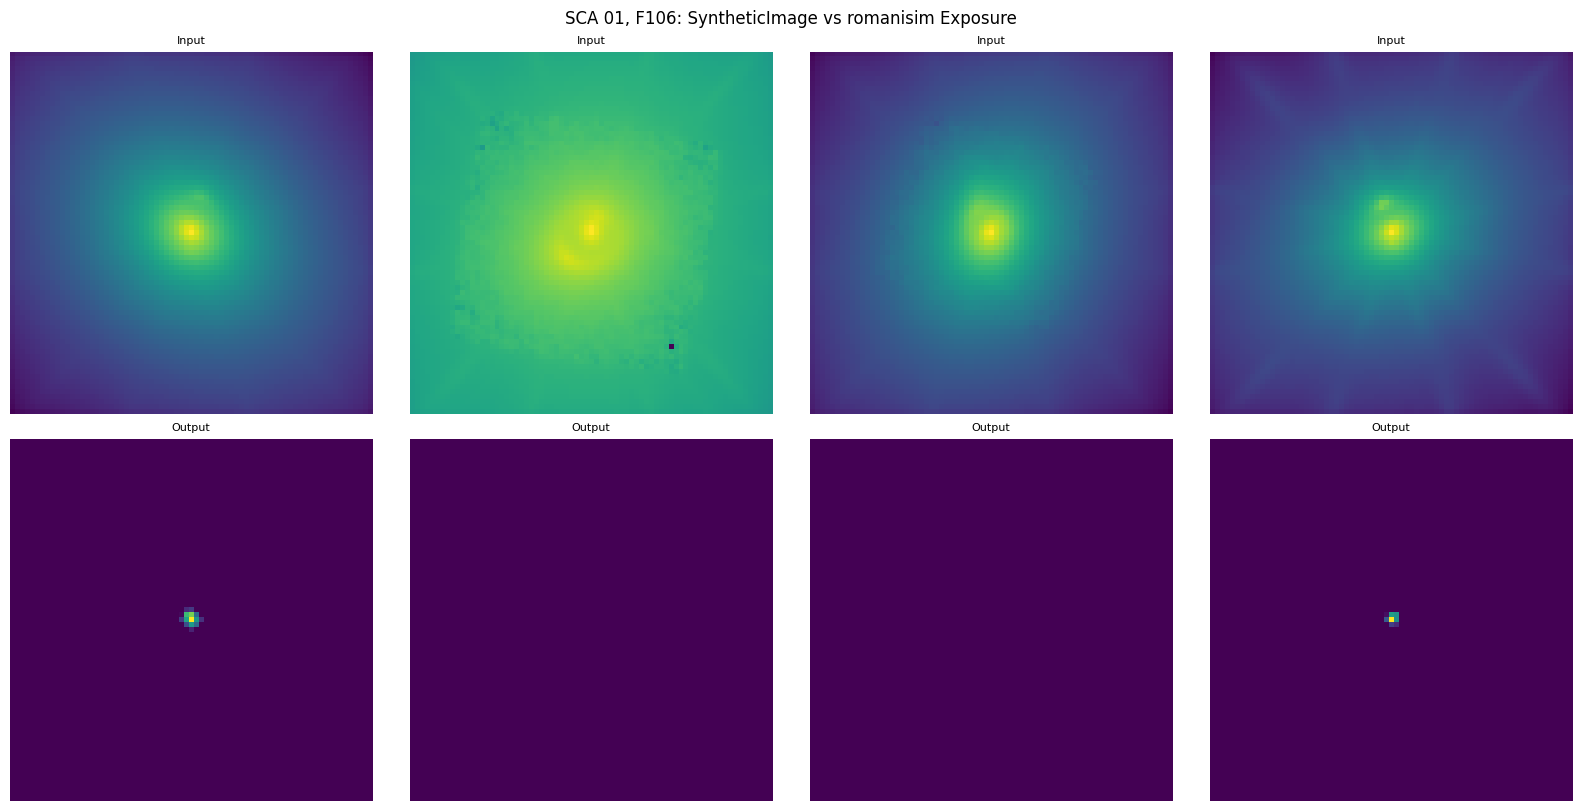

In [ ]:
# verification: compare input SyntheticImages with output cutouts
sample_sca = sorted(pickles_by_sca_band.keys())[0]
sample_band = bands[0]
sample_pickles = pickles_by_sca_band[sample_sca][sample_band][:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)

for i, pickle_path in enumerate(sample_pickles):
    synth = mejiro_util.unpickle(pickle_path)
    output_name = os.path.basename(pickle_path).replace('.pkl', '.npy').replace('SyntheticImage_', 'Exposure_')
    cutout = np.load(os.path.join(output_dir, f'sca{str(sample_sca).zfill(2)}', output_name))

    axes[0, i].imshow(np.log10(np.clip(synth.data, 1e-10, None)), origin='lower')
    axes[0, i].set_title('Input', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(np.log10(np.clip(cutout, 1, None)), origin='lower')
    axes[1, i].set_title('Output', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle(f'SCA {sample_sca:02d}, {sample_band}: SyntheticImage vs romanisim Exposure')
plt.show()